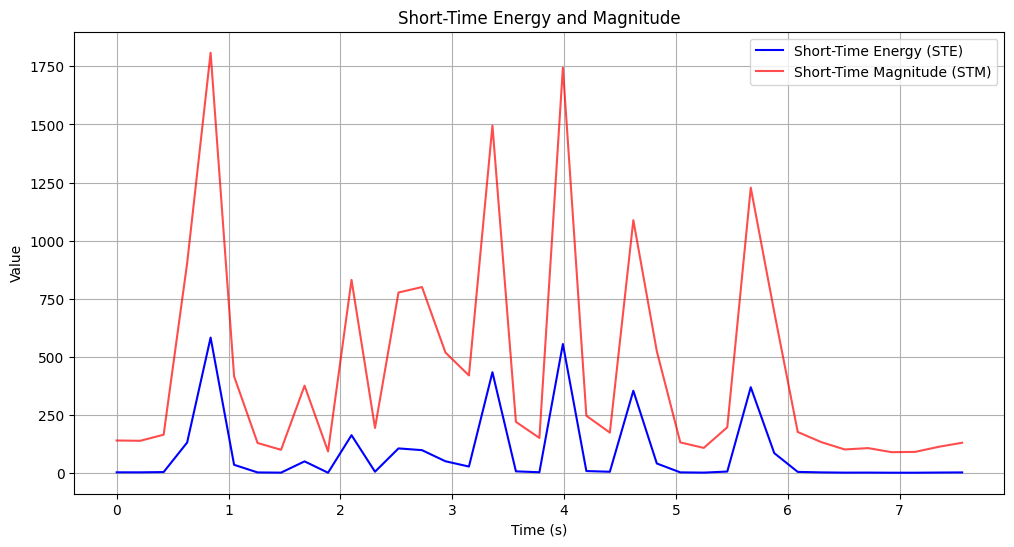

In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# Function to compute:
# 1. Short-Time Energy (STE)
# 2. Short-Time Magnitude (STM)
# =========================================================
def compute_ste_stm(audio_path, frame_length_ms=300, overlap_percent=0.3):

    # Load speech audio
    y, sr = librosa.load(audio_path, sr=None)

    # Calculate frame size and hop size in samples
    frame_size = int(sr * (frame_length_ms / 1000.0))
    hop_size = int(frame_size * (1.0 - overlap_percent))

    # Calculate number of frames
    num_frames = 1 + (len(y) - frame_size) // hop_size

    # Initialize arrays
    ste = np.zeros(num_frames)
    stm = np.zeros(num_frames)

    # Hamming window
    window = np.hamming(frame_size)

    # Compute STE and STM for each frame
    for i in range(num_frames):

        start = i * hop_size
        end = start + frame_size

        # Extract frame
        frame = y[start:end]
        
        # Pad with zeros if we are at the end of the signal
        if len(frame) < frame_size:
            frame = np.pad(frame, (0, frame_size - len(frame)), mode='constant')

        # Apply Hamming window
        windowed_frame = frame * window

        # -----------------------------
        # Short-Time Energy (STE)
        # -----------------------------
        ste[i] = np.sum(windowed_frame ** 2)

        # -----------------------------
        # Short-Time Magnitude (STM)
        # -----------------------------
        stm[i] = np.sum(np.abs(windowed_frame))

    return ste, stm, sr, hop_size


# =========================================================
# Function to visualize STE and STM
# =========================================================
def visualize_ste_stm(ste, stm, sr, hop_size):

    # Create time axis
    times = librosa.frames_to_time(
        np.arange(len(ste)),
        sr=sr,
        hop_length=hop_size
    )

    # Plot
    plt.figure(figsize=(12, 6))

    plt.plot(
        times,
        ste,
        label='Short-Time Energy (STE)',
        color='blue'
    )

    plt.plot(
        times,
        stm,
        label='Short-Time Magnitude (STM)',
        color='red',
        alpha=0.7
    )

    plt.xlabel("Time (s)")
    plt.ylabel("Value")
    plt.title("Short-Time Energy and Magnitude")

    plt.legend()
    plt.grid(True)

    plt.show()


# =========================================================
# Example Usage
# =========================================================
audio_path = r"C:\Users\Admin\Desktop\SLP301\practice_analysis\Thoại 260518_163911_1.wav"

ste, stm, sr, hop_size = compute_ste_stm(audio_path, frame_length_ms=300, overlap_percent=0.3)

visualize_ste_stm(ste, stm, sr, hop_size)